In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
from collections import defaultdict, Counter
import os
import numpy as np
from scipy.spatial.distance import jensenshannon
import re
from sklearn.model_selection import train_test_split
import spacy
from sentence_transformers import SentenceTransformer 
import umap
from bertopic import BERTopic

## 1 UK Reddit EDA

In [2]:
sandbox_df = pd.read_csv('../data/processed/train.csv')

In [3]:
sandbox_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url,combined_text,word_count
0,1e7svce,1.721472e+09,tories,Another W from Lammy,NaN,1,4,https://www.reddit.com/gallery/1e7svce,Another W from Lammy,4
1,1fnedkq,1.727074e+09,unitedkingdom,UK weather live: Met Office issues rare amber ...,NaN,11,6,https://www.independent.co.uk/news/uk/home-new...,UK weather live: Met Office issues rare amber ...,15
2,1e26fz6,1.720863e+09,ukpolitics,"MPs' safety keeps me 'awake at night,' says Sp...",NaN,36,10,https://www.bbc.co.uk/news/articles/cl5yj83jq2no,"MPs' safety keeps me 'awake at night,' says Sp...",9
3,1dz92ai,1.720548e+09,unitedkingdom,More Than 130 Reform Candidates Ignoring Elect...,NaN,495,101,https://bylinetimes.com/2024/07/01/reform-uk-f...,More Than 130 Reform Candidates Ignoring Elect...,12
4,1ed9220,1.722059e+09,ukpolitics,Even Starmer has realised heat pumps are a tot...,[deleted],1,1,https://www.telegraph.co.uk/news/2024/07/26/ev...,Even Starmer has realised heat pumps are a tot...,10


### 1.1 Initial integrity check

- 10,249 posts for one month
- num_comments and score are int - good
- 6048 missing values in selftext - the column that contains the contents of the post. Bad - 59%

In [4]:
# check num rows/cols
sandbox_df.shape

(24182, 10)

In [5]:
# check data types of cols
sandbox_df.dtypes

id                   str
created_utc      float64
subreddit            str
title                str
selftext             str
score              int64
num_comments       int64
url                  str
combined_text        str
word_count         int64
dtype: object

In [6]:
# null values check
null_vals = sandbox_df.isnull().sum()
null_vals

id                   0
created_utc          0
subreddit            0
title                0
selftext         14482
score                0
num_comments         0
url                371
combined_text        0
word_count           0
dtype: int64

In [7]:
# proportion null
null_vals/sandbox_df.shape[0]

id               0.000000
created_utc      0.000000
subreddit        0.000000
title            0.000000
selftext         0.598875
score            0.000000
num_comments     0.000000
url              0.015342
combined_text    0.000000
word_count       0.000000
dtype: float64

### 1.2 Class balances

In [8]:
# check subreddit counts
subr_counts = sandbox_df['subreddit'].value_counts()
subr_counts

subreddit
unitedkingdom    12121
ukpolitics        5922
LabourUK          1987
policeuk          1829
uknews            1273
reformuk           600
tories             293
brexit             147
gbnews               7
GreenPartyUK         3
Name: count, dtype: int64

In [9]:
# check for subreddit imbalances
subr_counts/sandbox_df.shape[0]

subreddit
unitedkingdom    0.501241
ukpolitics       0.244893
LabourUK         0.082169
policeuk         0.075635
uknews           0.052642
reformuk         0.024812
tories           0.012116
brexit           0.006079
gbnews           0.000289
GreenPartyUK     0.000124
Name: count, dtype: float64

### 1.3 Stats for virality

In [10]:
# descriptive stats
virality_cols_df = sandbox_df.loc[:, ['num_comments', 'score']]

virality_cols_df.describe()

,num_comments,score
count,24182.000000,24182.000000
mean,48.264577,61.162972
std,312.699914,283.033952
min,0.000000,0.000000
25%,0.000000,1.000000
50%,2.000000,1.000000
75%,24.000000,20.000000
max,36917.000000,15262.000000


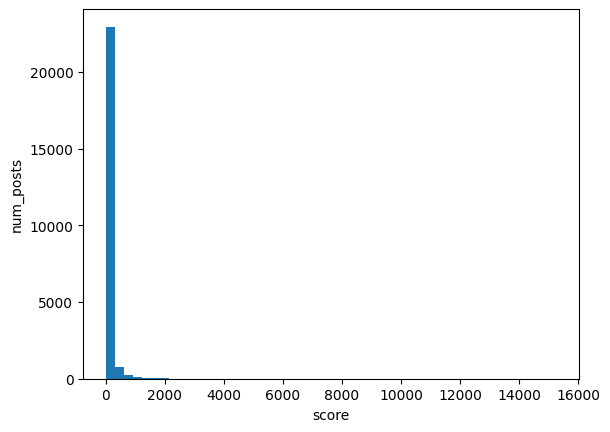

In [11]:
# Look at distribution of scores
plt.hist(virality_cols_df.loc[:, 'score'], bins=50)
plt.xlabel('score')
plt.ylabel('num_posts')
plt.show()

Vast majority of reddit posts have a score of <100. Big positive skew. Likely to need log transformed score for models

NB - score = num up votes - num down votes

In [12]:
# View top 10 highest scoring posts of the month 

sorted_by_score = sandbox_df.sort_values(by=['score'], ascending=False)
sorted_by_score.iloc[:10, :]

,id,created_utc,subreddit,title,selftext,score,num_comments,url,combined_text,word_count
19511,1ebq2on,1.721897e+09,uknews,Massive protest outside Rochdale police statio...,NaN,15262,2544,https://v.redd.it/r97e15b8pmed1,Massive protest outside Rochdale police statio...,14
8860,1fiu4ep,1.726563e+09,unitedkingdom,‘I’m selling 35 of my 65 rental homes – this i...,NaN,9302,1999,https://www.telegraph.co.uk/money/property/buy...,‘I’m selling 35 of my 65 rental homes – this i...,16
10337,1dvh7yh,1.720127e+09,unitedkingdom,"Labour set for 410-seat landslide, exit poll p...",NaN,8610,2633,https://www.telegraph.co.uk/politics/2024/07/0...,"Labour set for 410-seat landslide, exit poll p...",8
7450,1e9droj,1.721653e+09,unitedkingdom,One in six Conservative voters likely to die b...,NaN,8375,687,https://www.independent.co.uk/news/uk/politics...,One in six Conservative voters likely to die b...,13
5526,1fhywmj,1.726472e+09,unitedkingdom,"Young British men are NEETs—not in employment,...",NaN,8185,3056,https://fortune.com/2024/09/15/neets-british-g...,"Young British men are NEETs—not in employment,...",12
1363,1fnj2ol,1.727094e+09,unitedkingdom,Rachel Reeves announces free breakfast for pri...,NaN,7191,919,https://www.mirror.co.uk/news/politics/breakin...,Rachel Reeves announces free breakfast for pri...,11
2830,1e6zk1t,1.721381e+09,uknews,What has started the riots in Leeds?,NaN,6545,1976,https://v.redd.it/gsocg54w1gdd1,What has started the riots in Leeds?,7
8483,1eb3xtv,1.721834e+09,unitedkingdom,Shocking video shows police officer kicking ma...,NaN,6183,1713,https://www.lbc.co.uk/news/manchester-police-k...,Shocking video shows police officer kicking ma...,17
20326,1eku5df,1.722880e+09,uknews,Sky News journalist forced off air by muslim p...,NaN,6159,140,https://v.redd.it/l6u1z68quvgd1,Sky News journalist forced off air by muslim p...,11
12134,1edmr4y,1.722104e+09,unitedkingdom,New Manchester Airport video shows violent sce...,NaN,5418,2940,https://www.manchestereveningnews.co.uk/news/g...,New Manchester Airport video shows violent sce...,15


### 1.4 Text length

Title/body word counts and length stats. Useful to know for BERT classifier - has mac token limit of 512

In [13]:
sandbox_df['title_length'] = sandbox_df.loc[:, 'title'].str.split().str.len()
sandbox_df['body_length'] = sandbox_df.loc[:, 'selftext'].str.split().str.len()
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,combined_text,word_count,title_length,body_length
0,1e7svce,1.721472e+09,tories,Another W from Lammy,NaN,1,4,https://www.reddit.com/gallery/1e7svce,Another W from Lammy,4,4,NaN
1,1fnedkq,1.727074e+09,unitedkingdom,UK weather live: Met Office issues rare amber ...,NaN,11,6,https://www.independent.co.uk/news/uk/home-new...,UK weather live: Met Office issues rare amber ...,15,15,NaN
2,1e26fz6,1.720863e+09,ukpolitics,"MPs' safety keeps me 'awake at night,' says Sp...",NaN,36,10,https://www.bbc.co.uk/news/articles/cl5yj83jq2no,"MPs' safety keeps me 'awake at night,' says Sp...",9,9,NaN
3,1dz92ai,1.720548e+09,unitedkingdom,More Than 130 Reform Candidates Ignoring Elect...,NaN,495,101,https://bylinetimes.com/2024/07/01/reform-uk-f...,More Than 130 Reform Candidates Ignoring Elect...,12,12,NaN
4,1ed9220,1.722059e+09,ukpolitics,Even Starmer has realised heat pumps are a tot...,[deleted],1,1,https://www.telegraph.co.uk/news/2024/07/26/ev...,Even Starmer has realised heat pumps are a tot...,10,10,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
24177,1em9b4u,1.723030e+09,reformuk,If every person in the UK was educated on mass...,I find it hilarious how online specifically on...,90,148,https://www.reddit.com/r/reformuk/comments/1em...,If every person in the UK was educated on mass...,100,20,80.0
24178,1fs7k2n,1.727625e+09,uknews,Man dies after reports of 'large group fightin...,NaN,3,1,https://www.bbc.co.uk/news/articles/cy4d0mxr1w3o,Man dies after reports of 'large group fightin...,38,38,NaN
24179,1ehezqm,1.722514e+09,unitedkingdom,"Meet The Best Fighter in The world, From The U...",NaN,1,2,https://youtu.be/BD4DIRw-DB0?si=xjax_f-VKHBluEbP,"Meet The Best Fighter in The world, From The U...",14,14,NaN
24180,1fswuaa,1.727706e+09,policeuk,asked to make a statement in a misconduct inve...,[removed],1,0,https://www.reddit.com/r/policeuk/comments/1fs...,asked to make a statement in a misconduct inve...,16,16,1.0


In [14]:
sandbox_df.loc[:, ['title_length', 'body_length']].describe()

,title_length,body_length
count,24182.000000,9700.000000
mean,10.672566,37.009588
std,7.110573,113.735474
min,1.000000,0.000000
25%,6.000000,1.000000
50%,10.000000,1.000000
75%,13.000000,17.000000
max,65.000000,2560.000000


Merge title and body texts into single string. Anything with no selftext gets null replaced with an empty string. 

In [15]:
sandbox_df['selftext'] = sandbox_df['selftext'].str.replace(r'\[removed\]|\[deleted\]', '', regex=True)

In [16]:
sandbox_df['combined_text'] = sandbox_df['title'].str.cat(sandbox_df['selftext'], sep='', na_rep='')
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,combined_text,word_count,title_length,body_length
0,1e7svce,1.721472e+09,tories,Another W from Lammy,NaN,1,4,https://www.reddit.com/gallery/1e7svce,Another W from Lammy,4,4,NaN
1,1fnedkq,1.727074e+09,unitedkingdom,UK weather live: Met Office issues rare amber ...,NaN,11,6,https://www.independent.co.uk/news/uk/home-new...,UK weather live: Met Office issues rare amber ...,15,15,NaN
2,1e26fz6,1.720863e+09,ukpolitics,"MPs' safety keeps me 'awake at night,' says Sp...",NaN,36,10,https://www.bbc.co.uk/news/articles/cl5yj83jq2no,"MPs' safety keeps me 'awake at night,' says Sp...",9,9,NaN
3,1dz92ai,1.720548e+09,unitedkingdom,More Than 130 Reform Candidates Ignoring Elect...,NaN,495,101,https://bylinetimes.com/2024/07/01/reform-uk-f...,More Than 130 Reform Candidates Ignoring Elect...,12,12,NaN
4,1ed9220,1.722059e+09,ukpolitics,Even Starmer has realised heat pumps are a tot...,,1,1,https://www.telegraph.co.uk/news/2024/07/26/ev...,Even Starmer has realised heat pumps are a tot...,10,10,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
24177,1em9b4u,1.723030e+09,reformuk,If every person in the UK was educated on mass...,I find it hilarious how online specifically on...,90,148,https://www.reddit.com/r/reformuk/comments/1em...,If every person in the UK was educated on mass...,100,20,80.0
24178,1fs7k2n,1.727625e+09,uknews,Man dies after reports of 'large group fightin...,NaN,3,1,https://www.bbc.co.uk/news/articles/cy4d0mxr1w3o,Man dies after reports of 'large group fightin...,38,38,NaN
24179,1ehezqm,1.722514e+09,unitedkingdom,"Meet The Best Fighter in The world, From The U...",NaN,1,2,https://youtu.be/BD4DIRw-DB0?si=xjax_f-VKHBluEbP,"Meet The Best Fighter in The world, From The U...",14,14,NaN
24180,1fswuaa,1.727706e+09,policeuk,asked to make a statement in a misconduct inve...,,1,0,https://www.reddit.com/r/policeuk/comments/1fs...,asked to make a statement in a misconduct inve...,16,16,1.0


In [17]:
# check length of combined text
sandbox_df['combined_text_length'] = sandbox_df.loc[:, 'combined_text'].str.split().str.len()
sandbox_df['combined_text_length'].describe()

count    24182.000000
mean        25.142006
std         74.136645
min          1.000000
25%          7.000000
50%         11.000000
75%         15.000000
max       2566.000000
Name: combined_text_length, dtype: float64

If using words as tokens, the majority of posts will fall below the BERT token limit

### 1.5 Domain Profiling

Extract the core base domains (e.g., bbc.co.uk, theguardian.com) from raw url column - useful for weak supervision labelling

Big mix of outlets (all of the main ones you'd expect to see)

In [18]:
# use urlparse to get domains out of urls
sandbox_df['domains'] = sandbox_df['url'].fillna('').astype(str).apply(lambda x: urlparse(x).netloc).str.replace('www.', '')
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,combined_text,word_count,title_length,body_length,combined_text_length,domains
0,1e7svce,1.721472e+09,tories,Another W from Lammy,NaN,1,4,https://www.reddit.com/gallery/1e7svce,Another W from Lammy,4,4,NaN,4,reddit.com
1,1fnedkq,1.727074e+09,unitedkingdom,UK weather live: Met Office issues rare amber ...,NaN,11,6,https://www.independent.co.uk/news/uk/home-new...,UK weather live: Met Office issues rare amber ...,15,15,NaN,15,independent.co.uk
2,1e26fz6,1.720863e+09,ukpolitics,"MPs' safety keeps me 'awake at night,' says Sp...",NaN,36,10,https://www.bbc.co.uk/news/articles/cl5yj83jq2no,"MPs' safety keeps me 'awake at night,' says Sp...",9,9,NaN,9,bbc.co.uk
3,1dz92ai,1.720548e+09,unitedkingdom,More Than 130 Reform Candidates Ignoring Elect...,NaN,495,101,https://bylinetimes.com/2024/07/01/reform-uk-f...,More Than 130 Reform Candidates Ignoring Elect...,12,12,NaN,12,bylinetimes.com
4,1ed9220,1.722059e+09,ukpolitics,Even Starmer has realised heat pumps are a tot...,,1,1,https://www.telegraph.co.uk/news/2024/07/26/ev...,Even Starmer has realised heat pumps are a tot...,10,10,1.0,10,telegraph.co.uk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24177,1em9b4u,1.723030e+09,reformuk,If every person in the UK was educated on mass...,I find it hilarious how online specifically on...,90,148,https://www.reddit.com/r/reformuk/comments/1em...,If every person in the UK was educated on mass...,100,20,80.0,99,reddit.com
24178,1fs7k2n,1.727625e+09,uknews,Man dies after reports of 'large group fightin...,NaN,3,1,https://www.bbc.co.uk/news/articles/cy4d0mxr1w3o,Man dies after reports of 'large group fightin...,38,38,NaN,38,bbc.co.uk
24179,1ehezqm,1.722514e+09,unitedkingdom,"Meet The Best Fighter in The world, From The U...",NaN,1,2,https://youtu.be/BD4DIRw-DB0?si=xjax_f-VKHBluEbP,"Meet The Best Fighter in The world, From The U...",14,14,NaN,14,youtu.be
24180,1fswuaa,1.727706e+09,policeuk,asked to make a statement in a misconduct inve...,,1,0,https://www.reddit.com/r/policeuk/comments/1fs...,asked to make a statement in a misconduct inve...,16,16,1.0,16,reddit.com


In [19]:
domain_counts = sandbox_df['domains'].value_counts()
domain_counts

domains
reddit.com            8141
theguardian.com       1851
bbc.co.uk             1738
i.redd.it             1623
telegraph.co.uk        860
                      ... 
shado-mag.com            1
cumbriacrack.com         1
pressgazette.co.uk       1
steynonline.com          1
sco.lt                   1
Name: count, Length: 1081, dtype: int64

Want to see how data is distributed across political specturm (for political leaning label). Use https://mediabiasfactcheck.com/ to categorise the top 25 domains in the data. 

Very useful website for both political leaning and misinformation signals that you can get from the domain. 

For now, I'll look up the following fields for each of the domains:
- `bias` - ideological indicator
- `country` - geographic filter - interesting to see geographical spread of outlets publishing about UK politics/news
- `reporting` - factual quality scale, outlet's history of factually accurate reporting
- `credibility` - overall trust metric. 


Can use these to write LFs for both my validity/veracity label and my political bias label

In [20]:
top_25_domains = domain_counts[:25].index.tolist()
top_25_domains

['reddit.com',
 'theguardian.com',
 'bbc.co.uk',
 'i.redd.it',
 'telegraph.co.uk',
 'news.sky.com',
 'bbc.com',
 'x.com',
 'inews.co.uk',
 'independent.co.uk',
 'youtu.be',
 'thetimes.com',
 '',
 'youtube.com',
 'mirror.co.uk',
 'ft.com',
 'dailymail.co.uk',
 'standard.co.uk',
 'metro.co.uk',
 'v.redd.it',
 'lbc.co.uk',
 'itv.com',
 'politico.eu',
 'dailystar.co.uk',
 'bloomberg.com']

Only a small set for now so hard-coding a dict of the required MBFC categories for each domain 

In [21]:

mbfc_mapping = {
    # Internal Platform 
    "reddit.com": {"bias": "Platform/Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    "i.redd.it": {"bias": "Platform/Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    "v.redd.it": {"bias": "Platform/Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    "": {"bias": "Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    
    # Social Media
    "x.com": {"bias": "Unfiltered/Abstain", "reporting": "Low", "credibility": "Low"},
    "youtube.com": {"bias": "Unfiltered/Abstain", "reporting": "Mixed", "credibility": "Medium"},
    "youtu.be": {"bias": "Unfiltered/Abstain", "reporting": "Mixed", "credibility": "Medium"},
    
    # Left / Left-Center Outlets
    "theguardian.com": {"bias": "Left-Center", "reporting": "High", "credibility": "High"},
    "independent.co.uk": {"bias": "Left-Center", "reporting": "High", "credibility": "High"},
    "mirror.co.uk": {"bias": "Left-Center", "reporting": "High", "credibility": "High"},
    
    # --- Right / Right-Center Outlets ---
    "telegraph.co.uk": {"bias": "Right-Center", "reporting": "High", "credibility": "High"},
    "thetimes.com": {"bias": "Right-Center", "reporting": "High", "credibility": "High"},
    "dailymail.co.uk": {"bias": "Right", "reporting": "Mixed", "credibility": "Medium/Low"},
    "express.co.uk": {"bias": "Right", "reporting": "Mixed", "credibility": "Medium/Low"},
    
    # Center / Least Biased Outlets
    "bbc.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "bbc.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "news.sky.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "ft.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "inews.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "standard.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "metro.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "itv.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "lbc.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "politico.eu": {"bias": "Center", "reporting": "High", "credibility": "High"},
    
    # Questionable / Spam / Clickbait
    "usabestbusiness.com": {"bias": "Questionable", "reporting": "Low", "credibility": "Low"}
}


In [22]:
# Add columns with MBFC ratings
sandbox_df['political_bias'] = sandbox_df['domains'].apply(lambda x: mbfc_mapping.get(x, {}).get('bias', 'Abstain/Unknown'))
sandbox_df['reporting_quality'] = sandbox_df['domains'].apply(lambda x: mbfc_mapping.get(x, {}).get('reporting', 'Abstain/Unknown'))
sandbox_df['credibility'] = sandbox_df['domains'].apply(lambda x: mbfc_mapping.get(x, {}).get('credibility', 'Abstain/Unknown'))

# Crosstab subreddits with political bias 
polarisation_matrix = pd.crosstab(sandbox_df['subreddit'], sandbox_df['political_bias'])
polarisation_matrix

political_bias,Abstain,Abstain/Unknown,Center,Left-Center,Platform/Abstain,Questionable,Right,Right-Center,Unfiltered/Abstain
subreddit,,,,,,,,,
GreenPartyUK,0,0,0,0,3,0,0,0,0
LabourUK,17,636,307,413,487,0,9,69,49
brexit,2,38,17,31,46,0,0,6,7
gbnews,0,1,0,0,5,0,0,0,1
policeuk,22,43,61,14,1640,0,6,5,38
reformuk,10,48,18,3,441,0,6,19,55
tories,7,44,21,10,154,0,2,31,24
uknews,22,448,241,151,291,0,28,53,39
ukpolitics,76,1102,1202,886,1496,0,103,591,466


Loads of the dataset is unlabelled because the posts don't contain links to media outlets. Highlights the importance of analysing text/semantics, not just outward links, when assessing misinofrmation and political bias. Weak supervision and BERT will be a good choice for this.

Remove noise to see how politcal bias is spread across posts that do have links to most common domains

In [23]:
# Group all variation abstain columns together 
noise_columns = ['Abstain', 'Abstain/Unknown', 'Platform/Abstain', 'Unfiltered/Abstain']

# Drop them to isolate the core political news distribution
clear_signal_matrix = polarisation_matrix.drop(columns=noise_columns, errors='ignore')
clear_signal_matrix

political_bias,Center,Left-Center,Questionable,Right,Right-Center
subreddit,,,,,
GreenPartyUK,0,0,0,0,0
LabourUK,307,413,0,9,69
brexit,17,31,0,0,6
gbnews,0,0,0,0,0
policeuk,61,14,0,6,5
reformuk,18,3,0,6,19
tories,21,10,0,2,31
uknews,241,151,0,28,53
ukpolitics,1202,886,0,103,591


Dataset seeminly skewed left/centre-left but this something seems off here - expect a lot of right wing from reform, tories, gbnews etc. Think more about this 


Step 3: The Cross-Tabulation Matrix (The Polarization Check)
This is the most critical analytical step to prove whether your dataset is politically segregated. You want to see who is sharing what.

Generate a contingency table or a cross-tabulation matrix that matches your subreddits against your categorized ideological domains (Left vs. Right vs. Neutral).

Analyze the density: Do users in general spaces share an equal mix of Left and Right media? Do users in right-wing subreddits completely reject left-wing media domains (and vice versa)? This matrix visually maps the boundaries of polarization in your sandbox data.

Step 4: Text Style and Length Analysis Across Ideologies
Different political ecosystems often communicate using entirely different lexical styles, titles, and emotional weights.

Compute the character or word counts for both titles and body text across your data.

Group these length statistics by your ideological anchors. Check if one side of the spectrum relies more heavily on short, punchy, reactive titles, or if another side features massive, long-form text essays in their submissions. This establishes whether document length will be a confounding variable for your future BERT layers.

Step 5: Profile Engagement Metrics (The Virality Control Baseline)
To lay the groundwork for your future predictive models, you need to know if political ideology correlates with how fast or how widely a post spreads.

Calculate the summary statistics (mean, median, and max) for score (upvotes) and num_comments, grouped by political alignment.

Look for systemic differences: Do right-wing news articles get higher comment volumes but fewer upvotes? Does neutral news (like the BBC) receive steady, predictable engagement while partisan news shows massive, explosive spikes?

## 2. Cross-demographic distribution analysis

Need to ensure that there's enough resemblance (similarity in content and structure) in the data between the US and UK demographics. Means that training the misinformation classifier on the US data and the using it to help label the UK is a legitimate approach. 

### 2.1 Load and filter Fakeddit for news/polilitcs subreddits

In [24]:
fakeddit_path = os.path.join('..', 'data', 'raw', 'fakeddit', 'multimodal_train.tsv')
us_df = pd.read_csv(fakeddit_path, sep='\t')
print(us_df.shape)
us_df.head()

(564000, 16)


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


Since Fakeddit is primarily posts with images, there isn't a `selftext` col, so will just use `clean_title`. To ensure a fair comparison, **will only compare titles**

Inspect subreddits and select relevant ones to use for dataset filtering

In [25]:
us_df['subreddit'].value_counts()

subreddit
psbattle_artwork         167857
mildlyinteresting         86237
photoshopbattles          55198
pareidolia                47331
fakehistoryporn           35576
nottheonion               31977
upliftingnews             23960
fakealbumcovers           21725
misleadingthumbnails      15962
propagandaposters         13848
subredditsimulator        11553
confusing_perspective      8352
savedyouaclick             7721
theonion                   7548
neutralnews                7512
usnews                     5941
usanews                    5875
pic                        5381
satire                     3845
waterfordwhispersnews       363
subsimulatorgpt2            231
fakefacts                     7
Name: count, dtype: int64

In order to be able to compare the overlap of the two datasets, need to filter Fakeddit to the political/mews discourse. Some subreddits, e.g. fakealbumcovers, will not have much overlap with UK political reddits. 

In [26]:
# define fakeddit subreddits that map to real news-related commentary / satire
political_news_subs = ['neutralnews', 'usnews', 'usanews']


us_political_df = us_df[us_df['subreddit'].isin(political_news_subs)].copy()

print(f"Original Fakeddit Size: {us_df.shape[0]} rows")
print(f"Filtered Political/News Fakeddit Size: {us_political_df.shape[0]} rows")
print("\nFiltered row counts per subreddit:")
print(us_political_df['subreddit'].value_counts())

Original Fakeddit Size: 564000 rows
Filtered Political/News Fakeddit Size: 19328 rows

Filtered row counts per subreddit:
subreddit
neutralnews    7512
usnews         5941
usanews        5875
Name: count, dtype: int64


For initial comparison, want to ensure UK data is as purely political as possbile - will filter for a few specific subreddits and save as `uk_df` to match `us_df` naming 

In [27]:
uk_df = sandbox_df[sandbox_df['subreddit'].isin(['ukpolitics', 'reformuk', 'uknews', 'LabourUK']) ].copy()
uk_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url,combined_text,word_count,title_length,body_length,combined_text_length,domains,political_bias,reporting_quality,credibility
2,1e26fz6,1.720863e+09,ukpolitics,"MPs' safety keeps me 'awake at night,' says Sp...",NaN,36,10,https://www.bbc.co.uk/news/articles/cl5yj83jq2no,"MPs' safety keeps me 'awake at night,' says Sp...",9,9,NaN,9,bbc.co.uk,Center,High,High
4,1ed9220,1.722059e+09,ukpolitics,Even Starmer has realised heat pumps are a tot...,,1,1,https://www.telegraph.co.uk/news/2024/07/26/ev...,Even Starmer has realised heat pumps are a tot...,10,10,1.0,10,telegraph.co.uk,Right-Center,High,High
5,1fj2mcn,1.726588e+09,ukpolitics,How ‘stable’ Starmer won over far-right Meloni...,NaN,1,17,https://inews.co.uk/news/politics/stable-starm...,How ‘stable’ Starmer won over far-right Meloni...,12,12,NaN,12,inews.co.uk,Center,High,High
6,1ewsyu9,1.724153e+09,ukpolitics,King Charles III £1 coin enters circulation,NaN,1,1,https://www.bbc.com/news/articles/c3ejnv74dwno,King Charles III £1 coin enters circulation,7,7,NaN,7,bbc.com,Center,High,High
7,1ej7rcq,1.722703e+09,uknews,Reports that members of the Muslim Defence Lea...,NaN,1,0,https://www.reddit.com/gallery/1ej7rcq,Reports that members of the Muslim Defence Lea...,35,35,NaN,35,reddit.com,Platform/Abstain,Abstain,Abstain


Row counts for US and UK comparison datasets

In [28]:
print(f'UK comparison dataset row count: {uk_df.shape[0]}')
print(f'US comparison dataset row count: {us_df.shape[0]}')

UK comparison dataset row count: 9782
US comparison dataset row count: 564000


In [29]:
# Randomly sample US dataset to match UK sample size - don't want a class imbalance. Statify by subreddit 

us_df_sample, _ = train_test_split(
    us_political_df,
    train_size = len(uk_df),
    stratify=us_political_df['subreddit'],
    random_state=42
)

### 2.2 Lexical similarity

Use Jenson-Shannon divergence on unigram distributions. Run twice: once on raw data, once on blinded (replace region-specific words with generalised versions that can be compared, e.g. Farage, Biden = politician)

Distance metric for the **word distribution** of the two corpora

In [30]:
def tokenise(text): 
    text = text.lower().replace("'", '') # remove apostrophes to ensure words like that's vs thats don't become exclusive words between datasets
    return re.findall(r"[a-z']+", text.lower())

In [31]:
def counts(df, col):
    c = Counter()     # Counter = word: freq (dict)
    for t in df[col]:
        c.update(tokenise((t)))
    return c

In [32]:
us_counts = counts(us_df_sample, 'clean_title')
uk_counts = counts(uk_df, 'title')

# union of top-n from each dataset - create a shared vocab. The distributions for each dataset need t be over the same set of words. Use top-n to save on time
top_n = 10000
uk_top_n = set([w for w, _ in uk_counts.most_common(top_n)])
us_top_n = set([w for w, _ in us_counts.most_common(top_n)])
union = uk_top_n | us_top_n
vocab = sorted(union)

# Create sparse vectors for each word count dictionary. Position in each vector corresponds to the same word in shared vocab. 
us_vector = np.array([us_counts.get(w, 0) for w in vocab], dtype=float)
uk_vector = np.array([uk_counts.get(w, 0) for w in vocab], dtype=float)

# normalise each vector to create probability distributions
us_prob = us_vector / us_vector.sum()
uk_prob = uk_vector / uk_vector.sum()

# compute Jenson-Shannon divergence 
jsd = jensenshannon(us_prob, uk_prob, base=2) # use base 2 to ensure output is in range 0-1

print(f'JSD for UK pushift and US Fakeddit sample datasets = {jsd}')



JSD for UK pushift and US Fakeddit sample datasets = 0.5127837367951076


In [33]:
# Vocab intersection: how many of the top_n words appear in both lists? 

intersection = us_top_n & uk_top_n
print(f"US top-{top_n} vocab size:  {len(us_top_n):,}")
print(f"UK top-{top_n} vocab size:  {len(uk_top_n):,}")
print(f"Words in both:             {len(intersection):,}")
print(f"Words in either:           {len(union):,}")
print(f"Overlap (vs US top-N):     {len(intersection)/len(us_top_n):.1%}")
print(f"Overlap (vs UK top-N):     {len(uk_top_n & us_top_n)/len(uk_top_n):.1%}")
print(f"Jaccard:                   {len(intersection)/len(union):.1%}")

US top-10000 vocab size:  10,000
UK top-10000 vocab size:  10,000
Words in both:             5,014
Words in either:           14,986
Overlap (vs US top-N):     50.1%
Overlap (vs UK top-N):     50.1%
Jaccard:                   33.5%


Atm score is too high - anything above 0.5 suggests the datasets are quite different. But it's a really small sample atm - need to load in a few more months of UK data

Check what words are exclusive to each dataset:

In [34]:
us_only = us_top_n - uk_top_n
uk_only = uk_top_n - us_top_n

# Sort by frequency in their own corpus to see the most important words exclusively in each dataset
us_only_ranked = [(w, us_counts[w]) for w in us_only]
us_only_ranked.sort(key=lambda x: -x[1])

uk_only_ranked = [(w, uk_counts[w]) for w in uk_only]
uk_only_ranked.sort(key=lambda x: -x[1])

print('Top 30 words in US top-N but not UK top-N:')
for w, n in us_only_ranked[:30]: print(f'  {n:5d}  {w}')
print('\nTop 30 words in UK top-N but not US top-N:')
for w, n in uk_only_ranked[:30]: print(f'  {n:5d}  {w}')

Top 30 words in US top-N but not UK top-N:
    169  california
    153  senate
    150  fbi
    135  texas
    127  florida
    113  clinton
    103  gop
    101  mueller
     88  yearold
     86  obama
     74  mexico
     74  republican
     72  governor
     63  san
     62  chicago
     49  americas
     48  tariffs
     48  lawmakers
     47  obamacare
     46  carolina
     46  virginia
     46  ohio
     46  hillary
     45  shooter
     44  saudi
     44  sessions
     42  bipartisan
     42  sanders
     40  colorado
     39  puerto

Top 30 words in UK top-N but not US top-N:
    900  starmer
    520  keir
    263  tory
    207  farage
    207  reeves
    194  t
    177  tories
    149  nigel
    129  nhs
    120  southport
    105  snp
    100  megathread
     94  may
     89  sunak
     78  sir
     75  lib
     72  labours
     69  pensioners
     68  rayner
     67  starmers
     59  truss
     59  pro
     58  jeremy
     58  westminster
     57  covid
     56  tommy
    

Exclusive words to each dataset are primarily country-specific political 

Rerun JSD for blinded dataset - replace specific politician names with 'Politician', specific political party names with 'party'. Should lessen domain-specific differences and get a more general picture of when posts are using the same kinds of vocab. Filtering out geographical noise

Use spaCy's NER - spaCy automatically looks up PERSON and NORP (nationalities, orgs, religious/political groups). Saves typing out things to be blinded manually, more thorough. 

NB - need to use `title` instead of `clean_title` for fakeddit because spaCy is case-sensitive and has been trained using raw data, not lowercased. 

In [35]:
# Load lightweight pipeline 
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemma"])

# define blinding function 
def spacy_blind_raw_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    
    doc = nlp(text)
    token_list = []
    
    for token in doc:
        if token.ent_type == 'PERSON':
            token_list.append('[POLITICIAN]')
        if token.ent_type == 'NORP':
            token_list.append('[PARTY_OR_GROUP]')
        if token.ent_type == 'GPE':     
            token_list.append('[GEOGRAPHY]')      
        else:
            # keep rest of text lowecased for clean JS divergence 
            token_list.append(token.text.lower())
    
    # returns blinded set of text tokens ready for similarity calcs
    return " ".join(token_list) 

# apply blinder to both datasets

us_df_sample['blinded_title'] = us_df_sample['title'].apply(spacy_blind_raw_text)
uk_df['blinded_title'] = uk_df['title'].apply(spacy_blind_raw_text)

Now run JS divergence calculation on blinded datasets

In [36]:
# load spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemma"])


# Pull top 50 unique words from previous raw metrics runs
top_50_us_exclusive = [w for w, _ in us_only_ranked[:50]]
top_50_uk_exclusive = [w for w, _ in uk_only_ranked[:50]]
dynamic_targets = set(top_50_us_exclusive + top_50_uk_exclusive)

# Define explicit mappings for demographic-specific words to ensure they get properly blinded in pipeline
unified_fallback_dict = {}

politicians_list = ['starmer', 'keir', 'farage', 'nigel', 'obama', 'trumps', 'truss', 'liz', 'reeves', 'tommy', 'robinson', 'yvette', 'jess', 'lynch']
groups_list = ['gop', 'nhs', 'americans', 'brits', 'canadian', 'indian', 'islamist', 'saudi', 'korean', 'snp']
geo_list = ['america', 'boston', 'colorado', 'florida', 'gaza', 'georgia', 'liverpool', 'mexico', 'michigan', 'santa', 'syria', 'texas', 'virginia', 'washington', 'westminster', 'wales']

for word in dynamic_targets:
    if word in politicians_list:
        unified_fallback_dict[word] = "[POLITICIAN]"
    elif word in groups_list:
        unified_fallback_dict[word] = "[PARTY_OR_GROUP]"
    elif word in geo_list:
        unified_fallback_dict[word] = "[GEOGRAPHY]"

def spacy_blinder(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    
    doc = nlp(text)
    token_list = []
    
    for token in doc:
        token_lower = token.text.lower()
        
        # Check standard NER first
        if token.ent_type_ == "PERSON" or token_lower in politicians_list:
            token_list.append("[POLITICIAN]")
        elif token.ent_type_ == "NORP" or token_lower in groups_list:
            token_list.append("[PARTY_OR_GROUP]")
        elif token.ent_type_ == "GPE" or token_lower in geo_list:
            token_list.append("[GEOGRAPHY]")
        # then check fallback hard-coded dict
        elif token_lower in unified_fallback_dict:
            token_list.append(unified_fallback_dict[token_lower])
        # rest of tokens are left alone
        else:
            token_list.append(token_lower)
            
    return " ".join(token_list)


# apply blinder to datasets
us_df_sample['blinded_title'] = us_df_sample['title'].apply(spacy_blinder)
uk_df['blinded_title'] = uk_df['title'].apply(spacy_blinder)

# recompute metrics using blinded data
us_counts_b = counts(us_df_sample, 'blinded_title')
uk_counts_b = counts(uk_df, 'blinded_title')

top_n = 10000
uk_top_n_b = set([w for w, _ in uk_counts_b.most_common(top_n)])
us_top_n_b = set([w for w, _ in us_counts_b.most_common(top_n)])

union_b = uk_top_n_b | us_top_n_b
vocab_b = sorted(union_b)
intersection_b = us_top_n_b & uk_top_n_b

us_vector_b = np.array([us_counts_b.get(w, 0) for w in vocab_b], dtype=float)
uk_vector_b = np.array([uk_counts_b.get(w, 0) for w in vocab_b], dtype=float)

# Normalise distributions
us_prob_b = us_vector_b / us_vector_b.sum()
uk_prob_b = uk_vector_b / uk_vector_b.sum()

# Compute JSD
jsd_b = jensenshannon(us_prob_b, uk_prob_b, base=2)


print(f"US top-{top_n} vocab size:           {len(us_top_n_b):,}")
print(f"UK top-{top_n} vocab size:           {len(uk_top_n_b):,}")
print(f"Shared words in intersection:      {len(intersection_b):,}")
print(f"Jaccard Overlap:                   {len(intersection_b)/len(union_b):.1%}")
print(f"BLINDED JSD SCORE:        {jsd_b:.4f}")

# Dataset exclusive word lists
us_only_b = us_top_n_b - uk_top_n_b
uk_only_b = uk_top_n_b - us_top_n_b

us_only_ranked_b = [(w, us_counts_b[w]) for w in us_only_b]
us_only_ranked_b.sort(key=lambda x: -x[1])

uk_only_ranked_b = [(w, uk_counts_b[w]) for w in uk_only_b]
uk_only_ranked_b.sort(key=lambda x: -x[1])

print('\nTop 10 words in US top-N but not UK top-N (Blinded):')
for w, n in us_only_ranked_b[:10]: print(f'  {n:5d}  {w}')
print('\nTop 10 words in UK top-N but not US top-N (Blinded):')
for w, n in uk_only_ranked_b[:10]: print(f'  {n:5d}  {w}')


US top-10000 vocab size:           10,000
UK top-10000 vocab size:           10,000
Shared words in intersection:      5,321
Jaccard Overlap:                   36.2%
BLINDED JSD SCORE:        0.4220

Top 10 words in US top-N but not UK top-N (Blinded):
    150  senate
    148  fbi
    142  federal
     74  governor
     57  mueller
     48  lawmakers
     47  tariffs
     43  shooter
     41  obamacare
     35  prosecutors

Top 10 words in UK top-N but not US top-N (Blinded):
    100  megathread
     78  sir
     69  pensioners
     62  tories
     48  https
     47  southport
     46  rioters
     45  sunak
     44  councillor
     39  freebies


Compare raw vs blinded results

In [37]:
metrics_data = {
    "Metric": [
        "US Vocab Size (Top-N)",
        "UK Vocab Size (Top-N)",
        "Shared Vocab (Intersection)",
        "Jaccard Vocabulary Overlap",
        "Jensen-Shannon Divergence (JSD)"
    ],
    "Raw Baseline": [
        f"{len(us_top_n):,}",
        f"{len(uk_top_n):,}",
        f"{len(intersection):,}",
        f"{len(intersection)/len(union):.1%}",
        f"{jsd:.4f}"
    ],
    "Blinded Pipeline": [
        f"{len(us_top_n_b):,}",
        f"{len(uk_top_n_b):,}",
        f"{len(intersection_b):,}",
        f"{len(intersection_b)/len(union_b):.1%}",
        f"{jsd_b:.4f}"
    ]
}


comparison_df = pd.DataFrame(metrics_data)

def calculate_shift(row):
    if "Overlap" in row["Metric"]:
        raw_val = float(row["Raw Baseline"].replace('%', ''))
        blind_val = float(row["Blinded Pipeline"].replace('%', ''))
        return f"{blind_val - raw_val:+.1f}%"
    elif "Divergence" in row["Metric"]:
        raw_val = float(row["Raw Baseline"])
        blind_val = float(row["Blinded Pipeline"])
        return f"{blind_val - raw_val:+.4f}"
    else:
        try:
            raw_val = int(row["Raw Baseline"].replace(',', ''))
            blind_val = int(row["Blinded Pipeline"].replace(',', ''))
            return f"{blind_val - raw_val:+_}"
        except:
            return "N/A"

comparison_df["Absolute Delta"] = comparison_df.apply(calculate_shift, axis=1)

# Display the beautiful summary table
display(comparison_df)


,Metric,Raw Baseline,Blinded Pipeline,Absolute Delta
0,US Vocab Size (Top-N),"10,000","10,000",+0
1,UK Vocab Size (Top-N),"10,000","10,000",+0
2,Shared Vocab (Intersection),"5,014","5,321",+307
3,Jaccard Vocabulary Overlap,33.5%,36.2%,+2.7%
4,Jensen-Shannon Divergence (JSD),0.5128,0.4220,-0.0908


### 2.3 Semantic embeddings 

Move beyond bag-of-words approach and capture semnatic meanings - tone, topic etc now a consideration 



In [38]:
N = 3000 # num samples per side

us_sample, _ = train_test_split(us_df_sample, train_size = N, stratify=us_df_sample['subreddit'], random_state=42)
uk_sample = uk_df.sample(N, random_state=42)

emb_model = SentenceTransformer('all-MiniLM-L6-v2')
us_emb = emb_model.encode(us_sample['clean_title'].to_list(), batch_size=64, show_progress_bar=True)
uk_emb = emb_model.encode(uk_sample['title'].to_list(), batch_size=64, show_progress_bar=True)

# save embeddings
np.save('us_emb.np',us_emb); np.save('uk_emb.np', uk_emb)
us_sample.to_parquet('us_sample.parquet', engine='fastparquet'); uk_sample.to_parquet('uk_sample.parquet', engine='fastparquet')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

### 2.4 UMAP visualisation + domain classifier

Visualise embeddings spatially - if lots of overlap between two groups, strong indicator that transfer will work well 

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


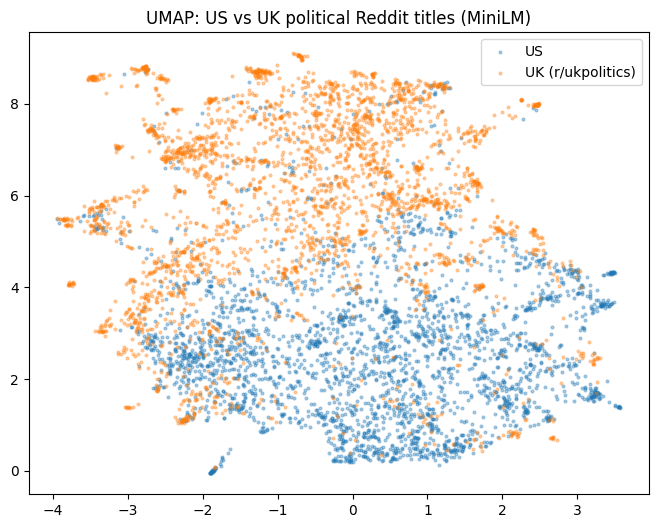

In [39]:
combined = np.vstack([us_emb, uk_emb])
reducer = umap.UMAP(n_neighbors=15, min_dist = 0.1, n_components=2, random_state=42)
projection = reducer.fit_transform(combined)
us_proj, uk_proj = projection[: len(us_emb)], projection[len(us_emb):]

plt.figure(figsize=(8,6))
plt.scatter(us_proj[:, 0], us_proj[:, 1], alpha=0.35, s=4, label='US')
plt.scatter(uk_proj[:,0], uk_proj[:,1], alpha=0.35, s=4, label='UK (r/ukpolitics)')
plt.legend()
plt.title('UMAP: US vs UK political Reddit titles (MiniLM)')
plt.savefig('UMAP_us_vs_uk.png', dpi=150, bbox_inches='tight')
plt.show()

Can see partial overlap with country-specific corners. One 'cloud', not two distinct clusters. Varying country densities within that cloud. So the genera semantic space is shared between the two regions - promising for transfer. The areas that appear to be more region-specific are likely related to language and topics that are region specific, e.g. 'Trump' for US and 'Brexit' for UK

From earlier JSD and Jaccard scores, can see that the two corpora are fairly lexically different, but semantically similar. Promising because BERT-based classifier will use semantic embeddings too. 

### 2.5 Engagement distribution shape

Show that user behaviour is comparable - want to know if the virality model trained on US data will generalise

- Want to avoid using raw scores - these will differ based on the sie of the subreddit subscriber base. Instead, plot the log of their scores and compare that distribution 

US political-news rows: 9,782
UK r/ukpolitics rows:   9,782


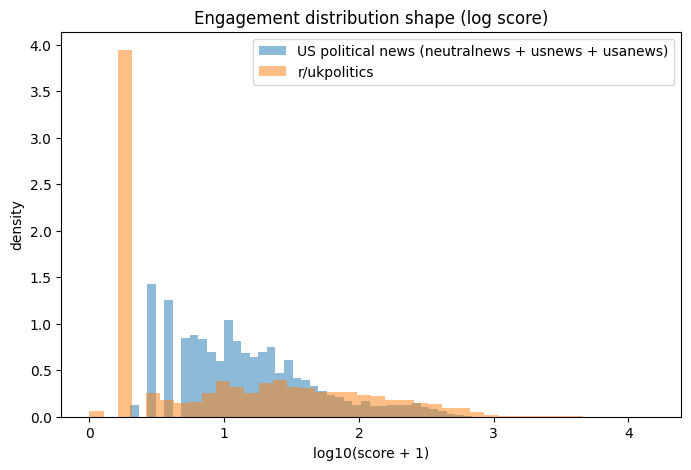

US political news: median=1.08, IQR=0.67, skew=0.79
r/ukpolitics: median=0.85, IQR=1.32, skew=0.69


In [40]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import skew

us_political_subs = ["neutralnews", "usnews", "usanews"]
us_pol_news = us_df_sample[us_df_sample["subreddit"].isin(us_political_subs)]
print(f"US political-news rows: {len(us_pol_news):,}")
print(f"UK r/ukpolitics rows:   {len(uk_df):,}")

us_log = np.log10(us_pol_news["score"].clip(lower=0) + 1)
uk_log = np.log10(uk_df["score"].clip(lower=0) + 1)

plt.figure(figsize=(8, 5))
plt.hist(us_log, bins=40, density=True, alpha=0.5, label="US political news (neutralnews + usnews + usanews)")
plt.hist(uk_log, bins=40, density=True, alpha=0.5, label="r/ukpolitics")
plt.xlabel("log10(score + 1)"); plt.ylabel("density"); plt.legend()
plt.title("Engagement distribution shape (log score)")
plt.savefig("engagement_logscore.png", dpi=150, bbox_inches="tight")
plt.show()

for name, x in [("US political news", us_log), ("r/ukpolitics", uk_log)]:
    if len(x) == 0:
        print(f"{name}: empty")
        continue
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    print(f"{name}: median={np.median(x):.2f}, IQR={iqr:.2f}, skew={skew(x):.2f}")

UK posts with score ≤ 2: 0.44622776528317315
US posts with score ≤ 2: 0.09834389695358822


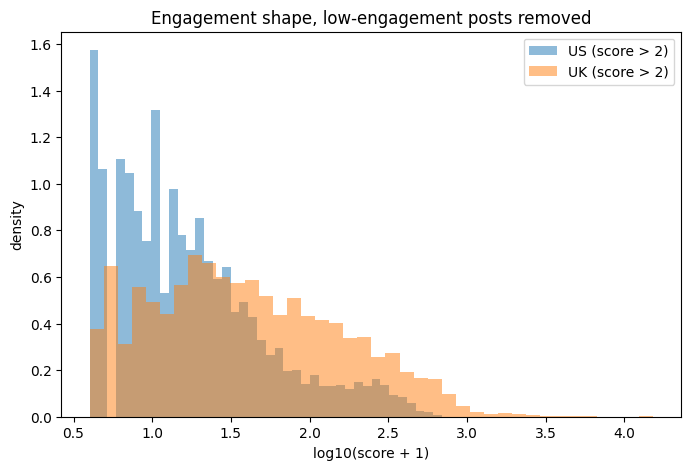

US (>2): median=1.15, IQR=0.65, skew=0.90
UK (>2): median=1.54, IQR=0.92, skew=0.39


In [41]:
# fraction of UK posts with score ≤ 2
print("UK posts with score ≤ 2:", (uk_df["score"] <= 2).mean())
print("US posts with score ≤ 2:", (us_pol_news["score"] <= 2).mean())

# Replot with the spike removed
us_log = np.log10(us_pol_news.loc[us_pol_news["score"] > 2, "score"] + 1)
uk_log = np.log10(uk_df.loc[uk_df["score"] > 2, "score"] + 1)

plt.figure(figsize=(8, 5))
plt.hist(us_log, bins=40, density=True, alpha=0.5, label="US (score > 2)")
plt.hist(uk_log, bins=40, density=True, alpha=0.5, label="UK (score > 2)")
plt.xlabel("log10(score + 1)"); plt.ylabel("density"); plt.legend()
plt.title("Engagement shape, low-engagement posts removed")
plt.show()

for name, x in [("US (>2)", us_log), ("UK (>2)", uk_log)]:
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    print(f"{name}: median={np.median(x):.2f}, IQR={iqr:.2f}, skew={skew(x):.2f}")

In [ ]:
for name, df, col in [("US (>2)", us_pol_news[us_pol_news["score"] > 2], "score"),
                       ("UK (>2)", uk_df[uk_df["score"] > 2], "score")]:
    p80 = np.percentile(df[col], 80)
    print(f"{name}: top-20% score threshold = {p80:.0f}, median = {df[col].median():.0f}")

US (>2): top-20% score threshold = 38, median = 13
UK (>2): top-20% score threshold = 141, median = 34


: 

- UK r/ukpolitics has a big spike around 0.3 for v low engagement posts (score of 1 or 2), then a log-normal. US politcal subreddits doesn't have low-engagment spike and is basically just log-normal. 
- After removing the UK low-engagement posts, both distributions follow a similar log-normal shape (right-skew, heavy tail). Similar shapes means virality behaviour cales similarly across two datasets.
- UK distribution is right-shifted compared to US - reflecting higher engagement in r/ukpolitcs are a flagship subreddit for discussion, vs lesser followed US politcs subreddits 
- Shifted distributions are OK, VIA is assessing relative virality within a given dataset. 

Top-20% virality thresholds differ between corpora (US: score ≥ 40; UK: score ≥ 154), reflecting r/ukpolitics' larger subscriber base and higher per-post engagement. Because VAI is computed as a within-corpus percentile, these absolute differences do not affect transferability — both pipelines predict relative virality, related to each corpus's own engagement distribution

### 2.6 Topic Overlap   

Use BERTopic to assess thematic overlap between the corpora 

In [ ]:
topic_us = BERTopic(verbose=True, calculate_probabilities=False)
topic_us.fit_transform(us_sample['clean_title'].tolist(), embeddings=us_emb)

topic_uk = BERTopic(verbose=True, calculate_probabilities=False)
topic_uk.fit_transform(uk_sample['title'].tolist(), embeddings=uk_emb)

print("US top topics:"); print(topic_us.get_topic_info().head(20))
print("UK top topics:"); print(topic_uk.get_topic_info().head(20))

2026-07-08 11:14:27,522 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Maintain one running notes file with everything you'll cite. By the end of this stage it should contain:

Filtered US and UK subreddit lists with row counts
JS distance (raw and entity-blinded, titles) + vocabulary intersection size
UMAP plot saved as PNG, with one-sentence reading
Domain classifier cross-val accuracy ± std
Engagement distribution plots (r/politics vs r/ukpolitics) + median/IQR/skew table
Topic overlap table (top 20 themes per side, paired where overlapping)
Sensitivity-check numbers from the broader UK set


